In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
import corner
import emcee
from scipy.optimize import differential_evolution

from mond_model import orbit_model_mond
from data_loader import S2DataLoader

## Defining Prameters

There are six keplerian parameters and one Mond parameter for modified acceleration.

In [18]:
PARAM_NAMES = ["a", "e", "i", "omega", "Omega", "T0", "M", "a0"]
PARAM_LABELS = [r"$a$ [$10^3$ AU]", r"$e$", r"$i$ [deg]", r"$\omega$ [deg]",
                r"$\Omega$ [deg]", r"$T_0$ [yr]", r"$M$ [$10^6\,M_\odot$]", r"$a_0$"]

## Loading Datasets

In [34]:
# ==============================================================================
loader = S2DataLoader()
loader.load_data()
data = loader.get_data()
 
t_ast, RA_obs, Dec_obs = data['t_ast'], data['ra_obs'], data['dec_obs']
sigma_RA, sigma_Dec = data['ra_err'], data['dec_err']
t_rv, RV_obs, sigma_RV = data['t_rv'], data['rv_obs'], data['rv_err']
n_ast = len(t_ast)
t_obs = np.concatenate([t_ast, t_rv])
 
print(f"n_astrometric={n_ast}, n_RV={len(t_rv)}")
print(f"t range: [{t_obs.min():.2f}, {t_obs.max():.2f}]")
print(f"RA range: [{RA_obs.min():.4f}, {RA_obs.max():.4f}] arcsec")
print(f"RV range: [{RV_obs.min():.1f}, {RV_obs.max():.1f}] km/s")

n_astrometric=145, n_RV=44
t range: [1992.22, 2016.53]
RA range: [-0.0391, 0.0712] arcsec
RV range: [-1571.0, 1199.0] km/s


## Setting Up Log Likelihood, Priors, and Bounds

In [37]:
def log_likelihood(theta):
    try:
        RA_mod, Dec_mod, RV_mod = orbit_model_mond(t_obs, theta, n_ast)
        chi2 = (np.sum(((RA_mod - RA_obs) / sigma_RA) ** 2) +
                np.sum(((Dec_mod - Dec_obs) / sigma_Dec) ** 2) +
                np.sum(((RV_mod - RV_obs) / sigma_RV) ** 2))
        return -0.5 * chi2 if np.isfinite(chi2) else -np.inf
    except Exception:
        return -np.inf

T0_LO, T0_HI = t_obs.min(), t_obs.max()
BOUNDS = [
    (0.3, 3.0),      # a, 1e3 AU
    (0.01, 0.98),    # e
    (0.0, 180.0),    # i, deg
    (0.0, 360.0),    # omega, deg
    (0.0, 360.0),    # Omega, deg
    (T0_LO, T0_HI),  # T0, yr
    (1.0, 8.0),      # M, 1e6 Msun
    (0.001, 0.5),    # a0
]

def log_prior(theta):
    for val, (lo, hi) in zip(theta, BOUNDS):
        if not (lo < val < hi):
            return -np.inf
    return 0.0

def log_posterior(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(theta)
    return lp + ll if np.isfinite(ll) else -np.inf

## MCMC

In [40]:
initial = np.array([
    1.03,     # a: ~1026 AU / 1000
    0.884,    # e
    134.2,    # i, deg
    66.1,     # omega, deg
    228.2,    # Omega, deg
    2018.38,  # T0, yr (most recent well-measured pericenter passage)
    4.30,     # M: ~4.30e6 Msun / 1e6
    0.05,     # a0
])
 
ndim = len(initial)
nwalkers = 20
spread = np.array([hi - lo for lo, hi in BOUNDS]) * 1e-3
pos = initial + spread * np.random.randn(nwalkers, ndim)
for j, (lo, hi) in enumerate(BOUNDS):
    pos[:, j] = np.clip(pos[:, j], lo + 1e-6, hi - 1e-6)
    
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
 
print("\nRunning MCMC until autocorrelation-time convergence...")
max_n = 500
index, old_tau = 0, np.inf
autocorr = np.empty(max_n)
t0 = time.time()
 
for _ in sampler.sample(pos, iterations=max_n, progress=True):
    if sampler.iteration % 100:
        continue
    tau = sampler.get_autocorr_time(tol=0)
    autocorr[index] = np.mean(tau)
    index += 1
    print(f"  step {sampler.iteration:6d}  mean_tau={np.mean(tau):8.1f}  "
          f"elapsed={time.time()-t0:7.1f}s", flush=True)
    converged = np.all(tau * 50 < sampler.iteration)
    converged &= np.all(np.abs(old_tau - tau) / tau < 0.01)
    if converged:
        print(f"Converged at iteration {sampler.iteration}")
        break
    old_tau = tau
else:
    print(f"Reached max_n={max_n} without formal convergence - "
          f"treat results as provisional.")
    
tau_final = sampler.get_autocorr_time(tol=0)
burn = int(2 * np.max(tau_final))
thin = max(1, int(0.5 * np.min(tau_final)))
samples = sampler.get_chain(discard=burn, thin=thin, flat=True)
print(f"Autocorrelation times: {dict(zip(PARAM_NAMES, np.round(tau_final, 1)))}")
print(f"burn-in={burn}, thin={thin}, "
      f"mean acceptance={np.mean(sampler.acceptance_fraction):.3f}")
print(f"Final sample count: {samples.shape[0]}")
 
theta_med = np.median(samples, axis=0)


Running MCMC until autocorrelation-time convergence...


 20%|██████████████████████████                                                                                                        | 100/500 [00:32<01:54,  3.49it/s]

  step    100  mean_tau=    10.2  elapsed=   33.9s


 40%|████████████████████████████████████████████████████                                                                              | 200/500 [01:09<02:05,  2.39it/s]

  step    200  mean_tau=    19.3  elapsed=   70.2s


...

  step    400  mean_tau=    38.5  elapsed=  164.4s


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [03:33<00:00,  1.83it/s]

  step    500  mean_tau=    49.7  elapsed=  214.2s


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [03:33<00:00,  2.34it/s]

Reached max_n=500 without formal convergence - treat results as provisional.
Autocorrelation times: {'a': np.float64(60.3), 'e': np.float64(59.0), 'i': np.float64(69.9), 'omega': np.float64(36.4), 'Omega': np.float64(48.8), 'T0': np.float64(1.0), 'M': np.float64(59.7), 'a0': np.float64(62.8)}
burn-in=139, thin=1, mean acceptance=0.394
Final sample count: 7220


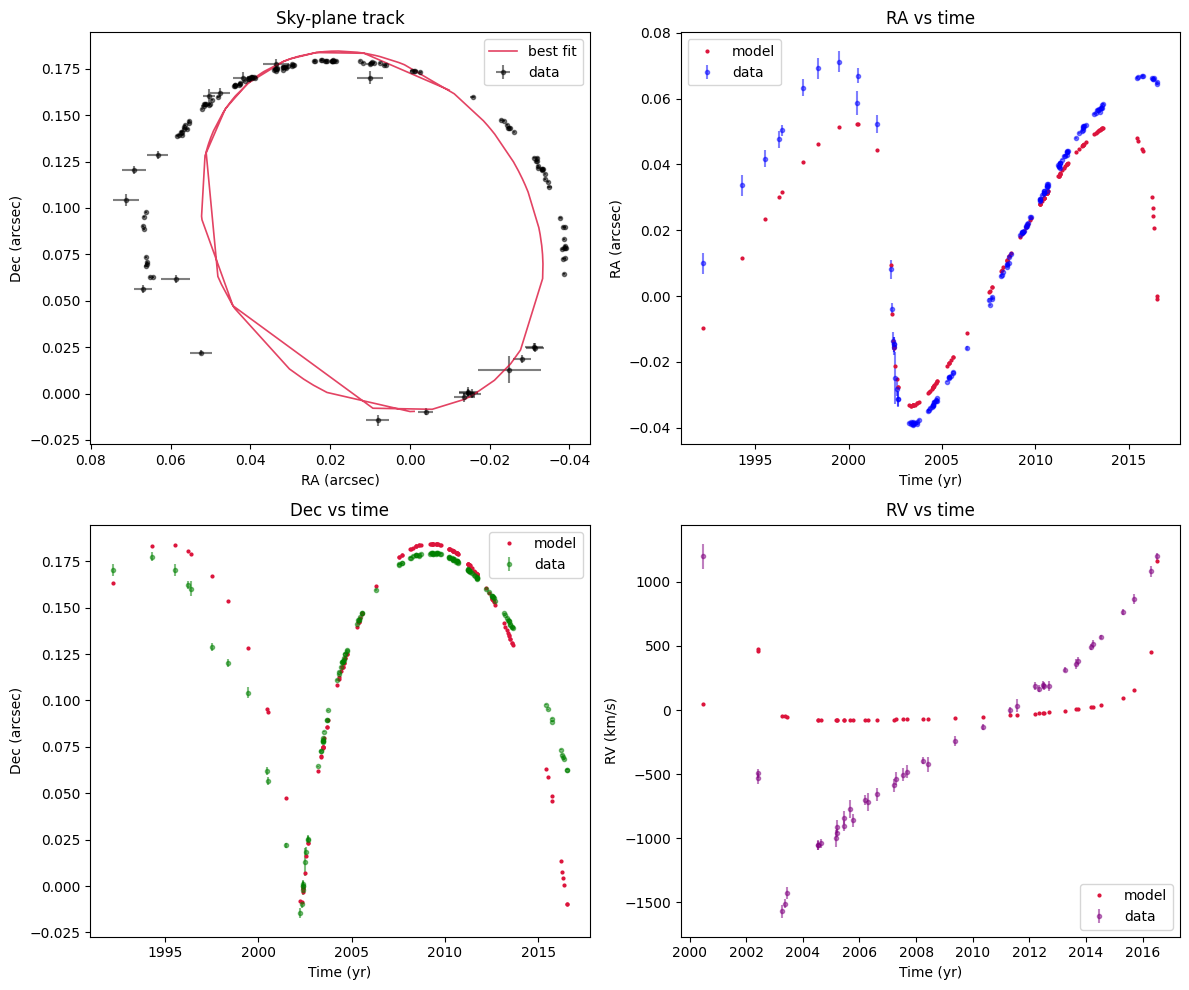

In [42]:
# best-fit overlay
RA_best, Dec_best, RV_best = orbit_model_mond(t_obs, theta_med, n_ast)
 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].errorbar(RA_obs, Dec_obs, xerr=sigma_RA, yerr=sigma_Dec, fmt='o',
                     color='black', markersize=3, alpha=0.5, label='data')
sort_idx = np.argsort(t_ast)
axes[0, 0].plot(RA_best[sort_idx], Dec_best[sort_idx], '-', color='crimson',
                 linewidth=1.2, alpha=0.8, label='best fit')
axes[0, 0].set(xlabel='RA (arcsec)', ylabel='Dec (arcsec)', title='Sky-plane track')
axes[0, 0].invert_xaxis()
axes[0, 0].legend()
 
axes[0, 1].errorbar(t_ast, RA_obs, yerr=sigma_RA, fmt='o', color='blue',
                     markersize=3, alpha=0.5, label='data')
axes[0, 1].plot(t_ast, RA_best, '.', color='crimson', markersize=4, label='model')
axes[0, 1].set(xlabel='Time (yr)', ylabel='RA (arcsec)', title='RA vs time')
axes[0, 1].legend()
 
axes[1, 0].errorbar(t_ast, Dec_obs, yerr=sigma_Dec, fmt='o', color='green',
                     markersize=3, alpha=0.5, label='data')
axes[1, 0].plot(t_ast, Dec_best, '.', color='crimson', markersize=4, label='model')
axes[1, 0].set(xlabel='Time (yr)', ylabel='Dec (arcsec)', title='Dec vs time')
axes[1, 0].legend()
 
axes[1, 1].errorbar(t_rv, RV_obs, yerr=sigma_RV, fmt='o', color='purple',
                     markersize=3, alpha=0.5, label='data')
axes[1, 1].plot(t_rv, RV_best, '.', color='crimson', markersize=4, label='model')
axes[1, 1].set(xlabel='Time (yr)', ylabel='RV (km/s)', title='RV vs time')
axes[1, 1].legend()
plt.tight_layout()
plt.savefig('bestfit_diagnostic2.pdf')
plt.show()